In [ ]:
from pathlib import Path

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

SYNTHETIC_DATA_DIR = REPO_ROOT / 'data' / 'synthetic'
RAW_DATA_DIR = REPO_ROOT / 'data' / 'raw'


## Free-Fall synthetic data
This notebook simulates one-dimensional free-fall motion and applies a standard 
linear Kalman filter to estimate velocity and acceleration from noisy IMU 
measurements corrupted by a Wiener-process bias. Five independent trials are 
run and evaluated against ground truth via RMSE.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
G           = 9.81
DT          = 0.01
T_TOTAL     = 2.0
T_RELEASE   = 0.3
T_IMPACT    = 1.5
N           = int(T_TOTAL / DT)
t           = np.arange(N) * DT
release_idx = int(T_RELEASE / DT) # Release occurs at 0.3s (30 samples in)
impact_idx  = int(T_IMPACT  / DT) # Impact occurs at 1.5s (150 samples in)
ff          = slice(release_idx, impact_idx)

# Noise parameters
SIGMA_N  = 0.05 # Measurement white noise
SIGMA_B0 = 0.3 # Initial bias in acceleration
SIGMA_B  = 0.05 # Bias random walk standard deviation

SEEDS    = [42, 7, 123, 256, 999]
N_TRIALS = len(SEEDS)


## Ground Truth & Filter Definition

In [9]:
# Ground truth trajectories
z_true  = np.zeros(N)
vz_true = np.zeros(N)
az_true = np.zeros(N)

for k in range(N):
    if release_idx <= k < impact_idx:
        tau        = t[k] - T_RELEASE
        z_true[k]  = 0.5 * G * tau**2 # z = 0.5 * g * t^2
        vz_true[k] = G * tau # vz = g * t
        az_true[k] = G
    elif k >= impact_idx:
        z_true[k] = 0.5 * G * (T_IMPACT - T_RELEASE)**2 


def make_imu(seed):
    """
    Simulates a noisy IMU accelerometer measurement for free-fall motion.

    The accelerometer measures specific force (i.e., true acceleration minus gravity),
    corrupted by a Wiener-process (random-walk) bias and added with white Gaussian noise.
    Gravity is then added back to recover the input signal used by the filter.

    Returns
    -------
    a_input : (N,) ndarray
        Noisy accelerometer input with gravity restored, in m/s².
    bias: (N,) ndarray
        The underlying bias in the accelerometer measurements, in m/s²
    """
    rng     = np.random.default_rng(seed)
    bias    = np.zeros(N)
    bias[0] = SIGMA_B0 * rng.standard_normal()
    for k in range(1, N):
        bias[k] = bias[k-1] + SIGMA_B * np.sqrt(DT) * rng.standard_normal() # Wiener process 
    a_meas  = (az_true - G) + bias + SIGMA_N * rng.standard_normal(N) # account for gravity in measurements
    a_input = a_meas + G
    return a_input, bias


def run_kalman_filter(a_input):
    """
    Standard linear KF  
    State:       x = [vz, az]
    Transition:  Phi = [[1, dt], [0, 1]] (velocity integrates acceleration, acceleration is constant)
    Measurement: H   = [0, 1]   (accelerometer observes az directly)
    """
    Phi = np.array([[1., DT], [0., 1.]])
    H   = np.array([[0., 1.]])
    Q   = np.diag([1e-3, (2 * SIGMA_N)**2]) # Process noise matrix
    R   = np.array([[SIGMA_N**2]]) # Measurement noise matrix

    x = np.zeros(2)
    P = np.diag([1., 1.])

    est    = np.zeros((N, 2))
    P_diag = np.zeros((N, 2))
    innov  = np.zeros(N)
    K_hist = np.zeros((N, 2))

    for k in range(N):
        # Predict
        x = Phi @ x
        P = Phi @ P @ Phi.T + Q
        # Update 
        y = np.array([a_input[k]]) - H @ x
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        x = x + (K @ y).flatten()
        P = (np.eye(2) - K @ H) @ P

        est[k]    = x
        P_diag[k] = np.diag(P)
        innov[k]  = y[0]
        K_hist[k] = K.flatten()

    z_est = np.zeros(N)
    for k in range(1, N):
        z_est[k] = z_est[k-1] + est[k, 0] * DT # integrate velocity to get position estimate

    return z_est, est, P_diag, innov, K_hist

def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

## Run 5 Trials of Synthetic Free Fall Data

In [10]:
results = np.zeros((N_TRIALS, 3)) 
traj    = {}

for i, seed in enumerate(SEEDS):
    a_input, bias_true = make_imu(seed)
    z_est, est, P_diag, innov, K_hist = run_kalman_filter(a_input)

    # compute rmse for position, velocity, and acceleration over the free-fall phase
    results[i] = [rmse(z_est[ff],    z_true[ff]),
                  rmse(est[ff, 0],   vz_true[ff]),
                  rmse(est[ff, 1],   az_true[ff])]

    traj[i] = dict(bias_true=bias_true, a_input=a_input,
                   z_est=z_est, est=est, P_diag=P_diag,
                   innov=innov, K_hist=K_hist)

    print(f"Trial {i+1}  seed={seed:>4d}  |  "
          f"z={results[i,0]:.4f} m  "
          f"vz={results[i,1]:.4f} m/s  "
          f"az={results[i,2]:.4f} m/s²")


Trial 1  seed=  42  |  z=0.0851 m  vz=0.0862 m/s  az=0.1780 m/s²
Trial 2  seed=   7  |  z=0.0060 m  vz=0.0662 m/s  az=0.1897 m/s²
Trial 3  seed= 123  |  z=0.1211 m  vz=0.2583 m/s  az=0.3169 m/s²
Trial 4  seed= 256  |  z=0.1411 m  vz=0.1868 m/s  az=0.2487 m/s²
Trial 5  seed= 999  |  z=0.1564 m  vz=0.2138 m/s  az=0.2697 m/s²


## Plot State Trajectories for All 5 Trials

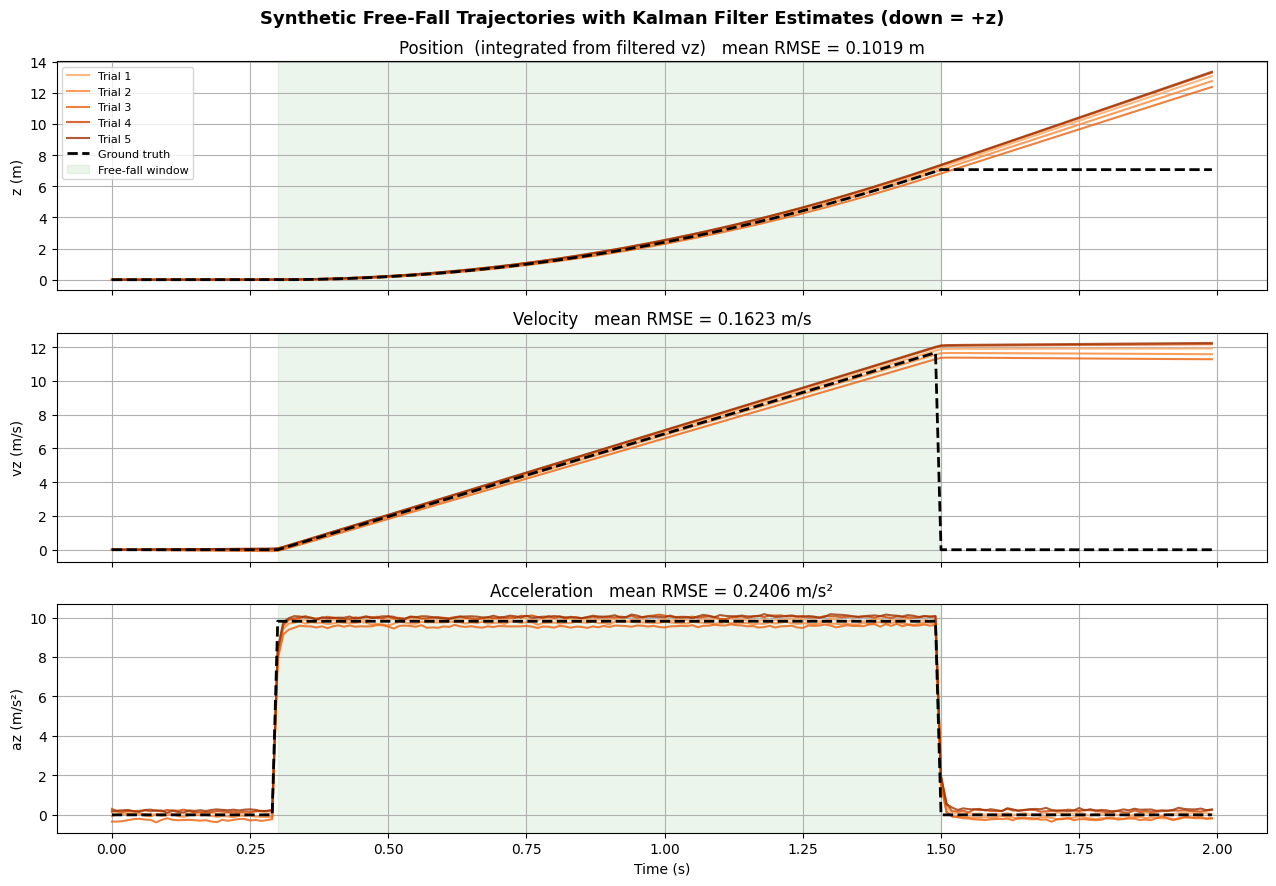

In [11]:
SPAN   = dict(color='green', alpha=0.08)
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, N_TRIALS))

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle('Synthetic Free-Fall Trajectories with Kalman Filter Estimates (down = +z)',
             fontsize=13, fontweight='bold')

for i in range(N_TRIALS):
    axes[0].plot(t, traj[i]['z_est'],      color=colors[i], alpha=0.8, label=f'Trial {i+1}')
    axes[1].plot(t, traj[i]['est'][:, 0],  color=colors[i], alpha=0.8)
    axes[2].plot(t, traj[i]['est'][:, 1],  color=colors[i], alpha=0.8)

axes[0].plot(t, z_true,  '--', color='black', lw=2, label='Ground truth')
axes[1].plot(t, vz_true, '--', color='black', lw=2)
axes[2].plot(t, az_true, '--', color='black', lw=2)

titles = [
    f'Position  (integrated from filtered vz)   mean RMSE = {results[:, 0].mean():.4f} m',
    f'Velocity   mean RMSE = {results[:, 1].mean():.4f} m/s',
    f'Acceleration   mean RMSE = {results[:, 2].mean():.4f} m/s²',
]

for j, (ax, yl, ti) in enumerate(zip(axes, ['z (m)', 'vz (m/s)', 'az (m/s²)'], titles)):
    ffall_label = 'Free-fall window' if j == 0 else '_'
    ax.axvspan(T_RELEASE, T_IMPACT, label=ffall_label, **SPAN)
    ax.set_ylabel(yl); ax.set_title(ti); ax.grid(True)

axes[0].legend(loc='upper left', fontsize=8)
axes[2].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()